# Step 1: Importing all Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")
import warnings
warnings.filterwarnings("ignore")

# Step 2: Load & Explore Dataset

In [2]:
df = pd.read_csv(r"C:\Users\HP\OneDrive\Desktop\IIT Internship\Bengaluru_House_Data.csv")
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


# Step 3: Understanding the Dataset

In [3]:
df.shape

(13320, 9)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [5]:
df.describe()

,bath,balcony,price
count,13247.000000,12711.000000,13320.000000
mean,2.692610,1.584376,112.565627
std,1.341458,0.817263,148.971674
min,1.000000,0.000000,8.000000
25%,2.000000,1.000000,50.000000
50%,2.000000,2.000000,72.000000
75%,3.000000,2.000000,120.000000
max,40.000000,3.000000,3600.000000


In [6]:
df.isnull().sum()

area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

# Step 4: Data Cleaning

In [7]:
df = df.drop("society", axis=1)

In [8]:
df = df.dropna(subset=['location'])
df = df.dropna(subset=['size'])

In [9]:
df['bath'] = df['bath'].fillna(df['bath'].median())
df['balcony'] = df['balcony'].fillna(df['balcony'].median())

In [10]:
df.isnull().sum()

area_type       0
availability    0
location        0
size            0
total_sqft      0
bath            0
balcony         0
price           0
dtype: int64

In [11]:
df = df.drop(['area_type', 'availability'], axis=1)
df.head()

,location,size,total_sqft,bath,balcony,price
0,Electronic City Phase II,2 BHK,1056,2.0,1.0,39.07
1,Chikka Tirupathi,4 Bedroom,2600,5.0,3.0,120.00
2,Uttarahalli,3 BHK,1440,2.0,3.0,62.00
3,Lingadheeranahalli,3 BHK,1521,3.0,1.0,95.00
4,Kothanur,2 BHK,1200,2.0,1.0,51.00


# Step 5: Creating BHK Feature

In [12]:
df['bhk'] = df['size'].apply(lambda x: int(x.split(' ')[0]))
df[['size', 'bhk']].head()

,size,bhk
0,2 BHK,2
1,4 Bedroom,4
2,3 BHK,3
3,3 BHK,3
4,2 BHK,2


In [13]:
df = df.drop('size', axis=1)

# Step 6: Cleaning total_sqft Column

In [14]:
def convert_sqft(x):
    x = str(x)
    
    if '-' in x:
        values = x.split('-')
        return (float(values[0]) + float(values[1])) / 2
    
    try:
        return float(x)
    except:
        return None

df['total_sqft'] = df['total_sqft'].apply(convert_sqft)

In [15]:
df = df.dropna(subset=['total_sqft'])

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13257 entries, 0 to 13319
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    13257 non-null  object 
 1   total_sqft  13257 non-null  float64
 2   bath        13257 non-null  float64
 3   balcony     13257 non-null  float64
 4   price       13257 non-null  float64
 5   bhk         13257 non-null  int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 725.0+ KB


# Step 7: Outlier Removal

In [17]:
df[df['total_sqft'] < 300].head()

,location,total_sqft,bath,balcony,price,bhk
119,Hennur Road,276.0,3.0,3.0,23.00,2
349,Suragajakkanahalli,11.0,3.0,2.0,74.00,3
1020,Weavers Colony,15.0,1.0,0.0,30.00,1
1122,Grihalakshmi Layout,24.0,2.0,2.0,150.00,5
2486,Bhoganhalli,296.0,1.0,0.0,22.89,1


In [18]:
df = df[df['total_sqft'] / df['bhk'] > 300]

In [19]:
df.shape

(12331, 6)

# Step 8: Exploratory Data Analysis (EDA)

## Correlation Matrix

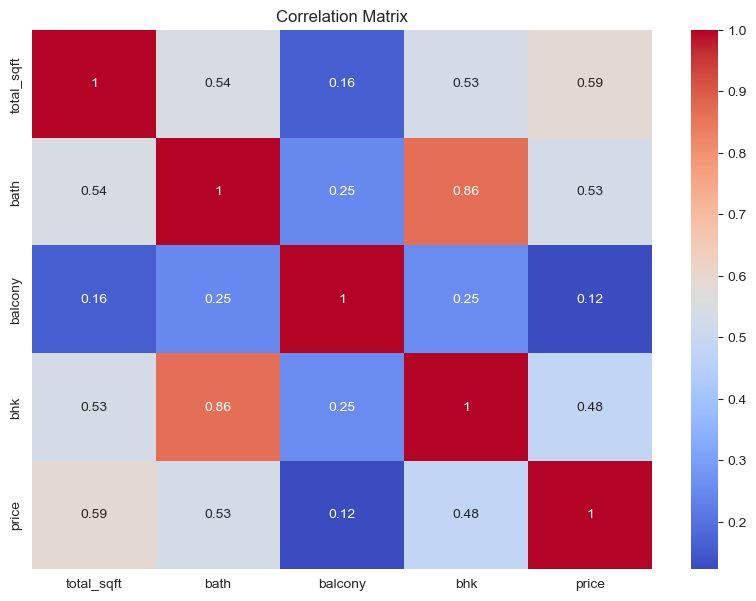

In [20]:
plt.figure(figsize=(10,7))
sns.heatmap(df[['total_sqft','bath','balcony','bhk','price']].corr(),
            annot=True,
            cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

## Plot 1: Price Distribution

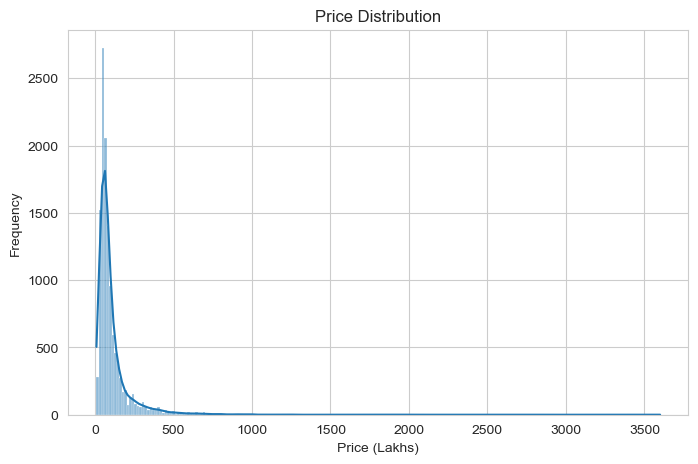

In [21]:
plt.figure(figsize=(8,5))
sns.histplot(df['price'], kde=True)
plt.title("Price Distribution")
plt.xlabel("Price (Lakhs)")
plt.ylabel("Frequency")
plt.show()

## Plot 2: Price vs Total Square Feet

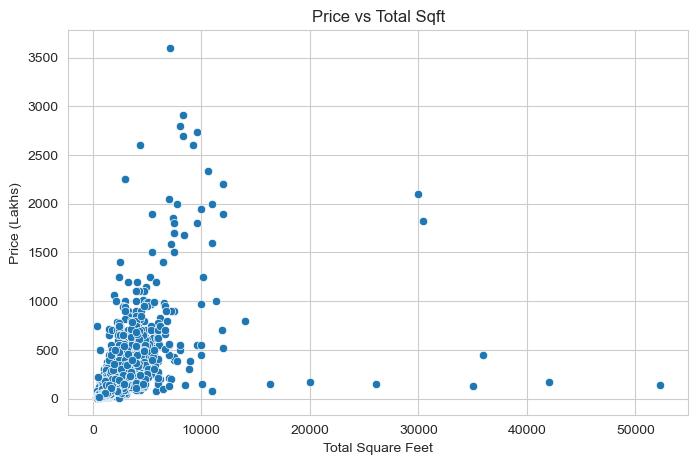

In [22]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='total_sqft', y='price', data=df)
plt.title("Price vs Total Sqft")
plt.xlabel("Total Square Feet")
plt.ylabel("Price (Lakhs)")
plt.show()

### Insight: 
Larger houses generally have higher prices.
Price increases as total_sqft increases.

## Plot 3: Price vs BHK

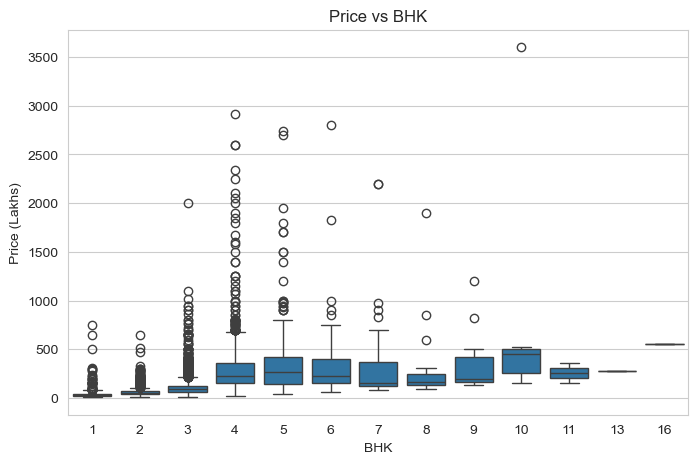

In [23]:
plt.figure(figsize=(8,5))
sns.boxplot(x='bhk', y='price', data=df)
plt.title("Price vs BHK")
plt.xlabel("BHK")
plt.ylabel("Price (Lakhs)")
plt.show()

### Insight:
Price increases with number of bedrooms.
Higher BHK properties have higher prices.

## 
Plot 4: Price vs Bathrooms

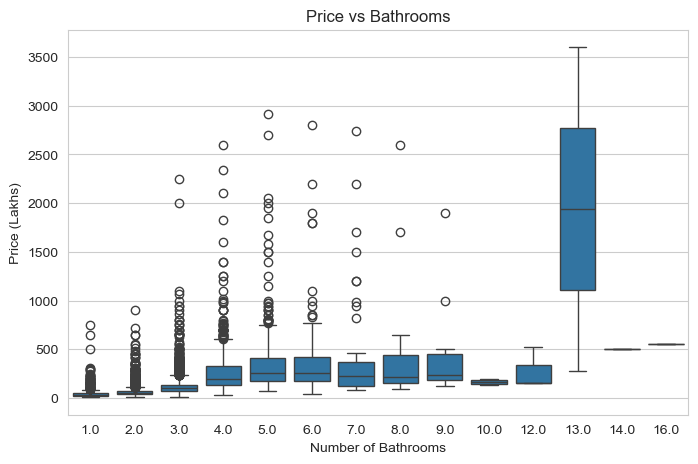

In [24]:
plt.figure(figsize=(8,5))
sns.boxplot(x='bath', y='price', data=df)
plt.title("Price vs Bathrooms")
plt.xlabel("Number of Bathrooms")
plt.ylabel("Price (Lakhs)")
plt.show()


### Insight:
More bathrooms tend to have higher prices.
it same as BHK

## Plot 5: Price vs Balcony

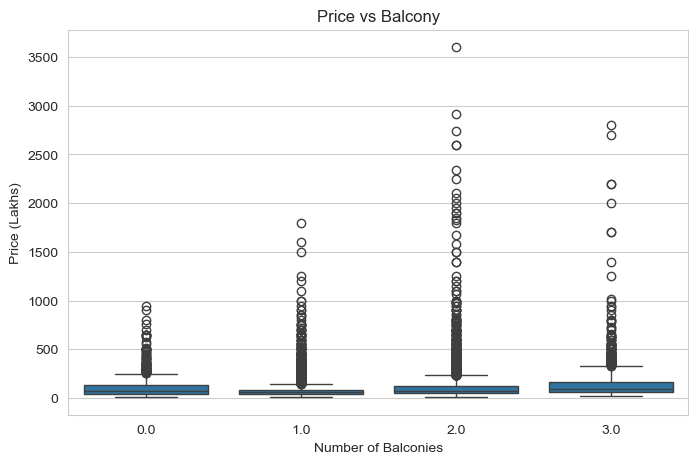

In [25]:
plt.figure(figsize=(8,5))
sns.boxplot(x='balcony', y='price', data=df)
plt.title("Price vs Balcony")
plt.xlabel("Number of Balconies")
plt.ylabel("Price (Lakhs)")
plt.show()

### Insight:
Balcony count has less impact on price compared to area, BHK, and bathrooms.

## Plot 6: Distribution of Total Square Feet

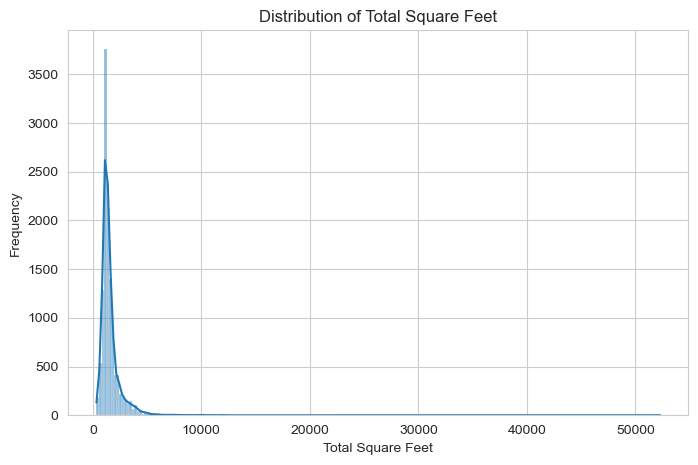

In [26]:
plt.figure(figsize=(8,5))
sns.histplot(df['total_sqft'], kde=True)
plt.title("Distribution of Total Square Feet")
plt.xlabel("Total Square Feet")
plt.ylabel("Frequency")
plt.show()

### Insight:
Total square footage is highly right-skewed.
Most properties are small to medium-sized,
while a few very large properties create a long tail.

## Plot 7: Distribution of BHK

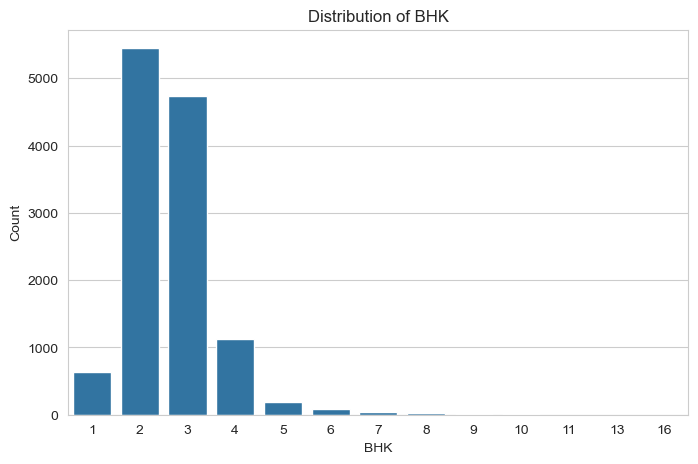

In [27]:
plt.figure(figsize=(8,5))
sns.countplot(x='bhk', data=df)
plt.title("Distribution of BHK")
plt.xlabel("BHK")
plt.ylabel("Count")
plt.show()

### Insight:
Most properties are 2 BHK and 3 BHK.

## Plot 8: Distribution of Bathrooms

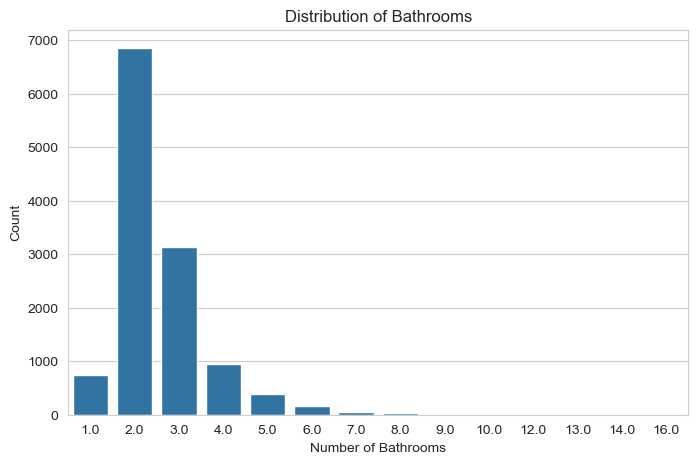

In [28]:
plt.figure(figsize=(8,5))
sns.countplot(x='bath', data=df)
plt.title("Distribution of Bathrooms")
plt.xlabel("Number of Bathrooms")
plt.ylabel("Count")
plt.show()

### Insight:
Same as the BHK most properties have 2 or 3 bathrooms.

## Plot 9: Top 10 Expensive Locations

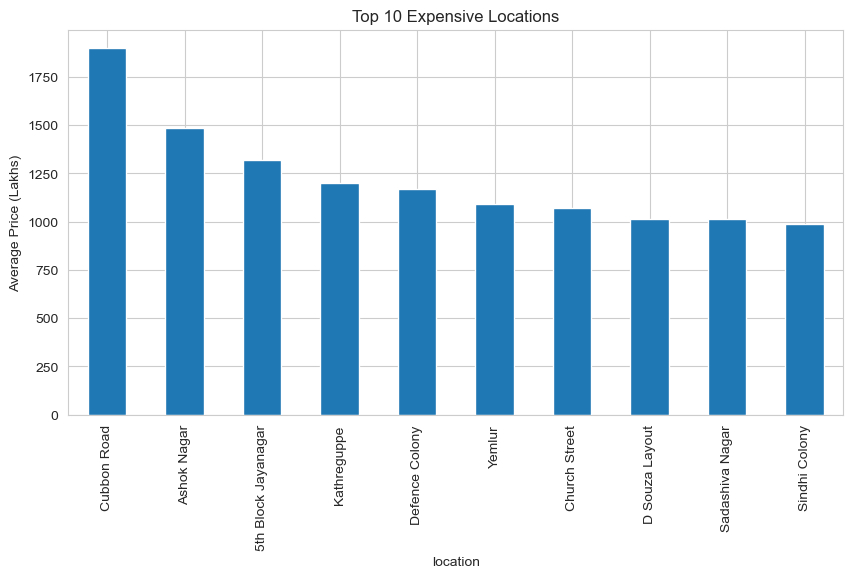

In [29]:
top_locations = df.groupby('location')['price'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_locations.plot(kind='bar')
plt.title("Top 10 Expensive Locations")
plt.ylabel("Average Price (Lakhs)")
plt.show()

### Insight:
Cubbon Road have significantly higher average property prices.

## Plot 10: Pairplot of Key Numerical Features

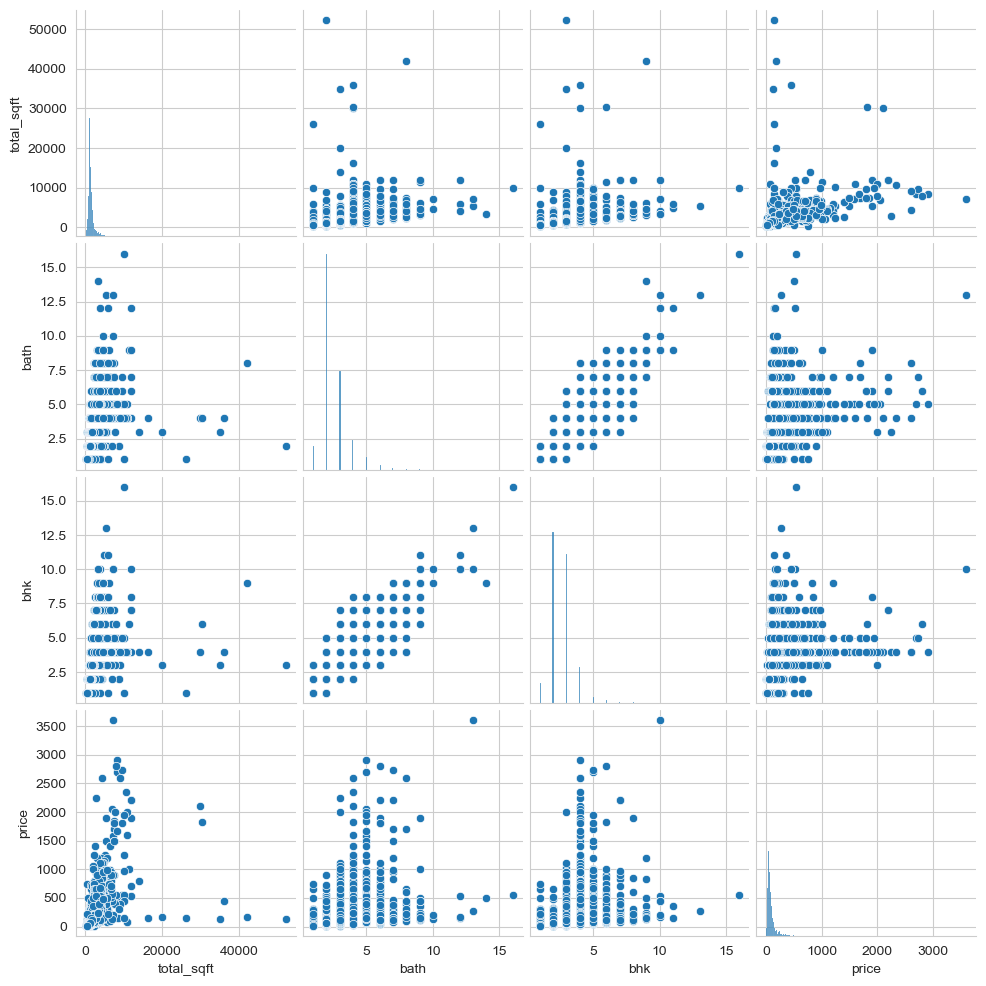

In [30]:
sns.pairplot(df[['total_sqft','bath','bhk','price']])
plt.show()

### Insight:
Price shows strong and positive relationship with total_sqft,Bathrooms and BHK

# Step 9: Feature Engineering
1. Creating a new feature: price_per_sqft
2. Handling skewness in price
3. Removing redundant or highly correlated columns

In [31]:
df['price_per_sqft'] = df['price'] / df['total_sqft']
df[['price','total_sqft','price_per_sqft']].head()

,price,total_sqft,price_per_sqft
0,39.07,1056.0,0.036998
1,120.00,2600.0,0.046154
2,62.00,1440.0,0.043056
3,95.00,1521.0,0.062459
4,51.00,1200.0,0.042500


In [32]:
df['price'].skew()

np.float64(8.067917216352624)

In [33]:
df['price_log'] = np.log(df['price'])
df[['price','price_log']].head()

,price,price_log
0,39.07,3.665355
1,120.00,4.787492
2,62.00,4.127134
3,95.00,4.553877
4,51.00,3.931826


In [34]:
df['price_log'].skew()

np.float64(0.9474621616706669)

In [35]:
df = df.drop(['price','price_per_sqft'], axis=1)
df.head()

,location,total_sqft,bath,balcony,bhk,price_log
0,Electronic City Phase II,1056.0,2.0,1.0,2,3.665355
1,Chikka Tirupathi,2600.0,5.0,3.0,4,4.787492
2,Uttarahalli,1440.0,2.0,3.0,3,4.127134
3,Lingadheeranahalli,1521.0,3.0,1.0,3,4.553877
4,Kothanur,1200.0,2.0,1.0,2,3.931826


# Outlier Removal using IQR (price_log,total_sqft)

In [36]:
Q1 = df['price_log'].quantile(0.25)
Q3 = df['price_log'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df = df[(df['price_log'] >= lower) & (df['price_log'] <= upper)]
df.shape

(11932, 6)

In [37]:
Q1 = df['total_sqft'].quantile(0.25)
Q3 = df['total_sqft'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df = df[(df['total_sqft'] >= lower) & (df['total_sqft'] <= upper)]
df.shape

(10983, 6)

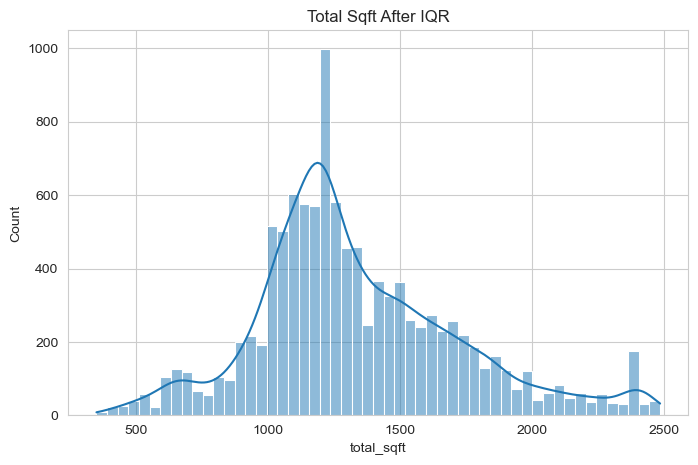

In [38]:
plt.figure(figsize=(8,5))
sns.histplot(df['total_sqft'], kde=True)
plt.title("Total Sqft After IQR")
plt.show()

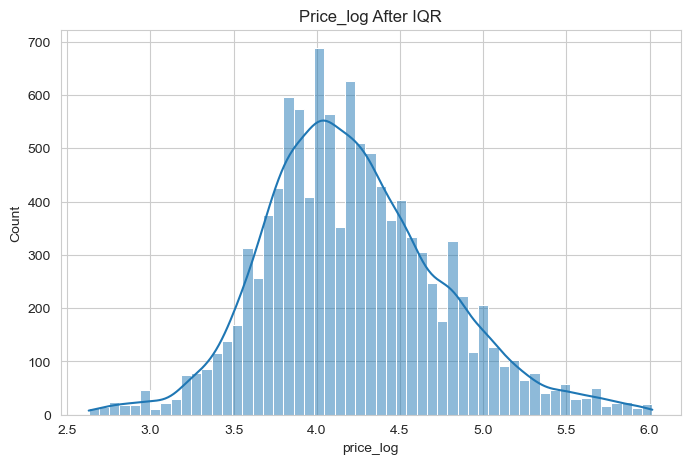

In [39]:
plt.figure(figsize=(8,5))
sns.histplot(df['price_log'], kde=True)
plt.title("Price_log After IQR")
plt.show()

# Step 10: Encoding Location Feature and Location Grouping

In [40]:
location_counts = df['location'].value_counts()
major_locations = location_counts[location_counts >= 10].index
df['location'] = df['location'].apply(
    lambda x: x if x in major_locations else 'Other'
)
df['location'].nunique()

215

In [41]:
df = pd.get_dummies(df, columns=['location'], drop_first=True)
df.head()

,total_sqft,bath,balcony,bhk,price_log,location_1st Phase JP Nagar,location_2nd Phase Judicial Layout,location_5th Phase JP Nagar,location_6th Phase JP Nagar,location_7th Phase JP Nagar,location_8th Phase JP Nagar,location_9th Phase JP Nagar,location_AECS Layout,location_Abbigere,location_Akshaya Nagar,location_Ambalipura,location_Ambedkar Nagar,location_Amruthahalli,location_Anandapura,location_Ananth Nagar,location_Anekal,location_Anjanapura,location_Ardendale,location_Arekere,location_Attibele,location_BEML Layout,location_BTM 2nd Stage,location_BTM Layout,location_Babusapalaya,location_Badavala Nagar,location_Balagere,location_Banashankari,location_Banashankari Stage III,location_Banashankari Stage V,location_Banaswadi,location_Bannerghatta,location_Bannerghatta Road,location_Basapura,location_Basavangudi,location_Basaveshwara Nagar,location_Battarahalli,location_Begur,location_Begur Road,location_Bellandur,location_Bharathi Nagar,location_Bhoganhalli,location_Billekahalli,location_Binny Pete,location_Bisuvanahalli,location_Bommanahalli,location_Bommasandra,location_Bommasandra Industrial Area,location_Brookefield,location_Budigere,location_CV Raman Nagar,location_Chamrajpet,location_Chandapura,location_Channasandra,location_Chikkalasandra,location_Choodasandra,location_Cooke Town,location_Cox Town,location_Dasanapura,location_Dasarahalli,location_Devanahalli,location_Dodda Nekkundi,location_Doddakallasandra,location_Doddathoguru,location_Domlur,location_Dommasandra,location_EPIP Zone,location_Electronic City,location_Electronic City Phase II,location_Electronics City Phase 1,location_Frazer Town,location_GM Palaya,location_Garudachar Palya,location_Gollarapalya Hosahalli,location_Gottigere,location_Green Glen Layout,location_Gubbalala,location_Gunjur,location_Gunjur Palya,location_HBR Layout,location_HRBR Layout,location_HSR Layout,location_Haralur Road,location_Harlur,location_Hebbal,location_Hebbal Kempapura,location_Hegde Nagar,location_Hennur,location_Hennur Road,location_Hoodi,location_Horamavu Agara,location_Horamavu Banaswadi,location_Hormavu,location_Hosa Road,location_Hosakerehalli,location_Hoskote,location_Hosur Road,location_Hulimavu,location_ITPL,location_Iblur Village,location_Indira Nagar,location_JP Nagar,location_Jakkur,location_Jalahalli,location_Jalahalli East,location_Jigani,location_Judicial Layout,location_KR Puram,location_Kadubeesanahalli,location_Kadugodi,location_Kaggadasapura,location_Kaggalipura,location_Kaikondrahalli,location_Kalena Agrahara,location_Kalkere,location_Kalyan nagar,location_Kambipura,location_Kammasandra,location_Kanakapura,location_Kanakpura Road,location_Kannamangala,location_Kasavanhalli,location_Kasturi Nagar,location_Kathriguppe,location_Kaval Byrasandra,location_Kenchenahalli,location_Kengeri,location_Kengeri Satellite Town,location_Kereguddadahalli,location_Kodichikkanahalli,location_Kodigehaali,location_Kogilu,location_Koramangala,location_Kothannur,location_Kothanur,location_Kudlu,location_Kudlu Gate,location_Kumaraswami Layout,location_Kundalahalli,location_LB Shastri Nagar,location_Lakshminarayana Pura,location_Lingadheeranahalli,location_Magadi Road,location_Mahadevpura,location_Mallasandra,location_Malleshpalya,location_Malleshwaram,location_Marathahalli,location_Margondanahalli,location_Mico Layout,location_Munnekollal,location_Murugeshpalya,location_Mysore Road,location_NGR Layout,location_NRI Layout,location_Nagappa Reddy Layout,location_Nagarbhavi,location_Nagavara,location_Nagavarapalya,location_Narayanapura,location_Neeladri Nagar,location_Nehru Nagar,location_OMBR Layout,location_Old Airport Road,location_Old Madras Road,location_Other,location_Padmanabhanagar,location_Pai Layout,location_Panathur,location_Parappana Agrahara,location_Pattandur Agrahara,location_Poorna Pragna Layout,location_Prithvi Layout,location_R.T. Nagar,location_Rachenahalli,location_Raja Rajeshwari Nagar,location_Rajaji Nagar,location_Rajiv Nagar,location_Ramagondanahalli,location_Ramam

In [42]:
df.shape

(10983, 219)

# Step 11: Model Building 

In [43]:
X = df.drop('price_log', axis=1)
y = df['price_log']
X.shape, y.shape

((10983, 218), (10983,))

# Step 12: Train-Test Split

In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train.shape, X_test.shape

((8786, 218), (2197, 218))

# Model 1: Linear Regression

In [45]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)
rmse_lr, mae_lr, r2_lr

(np.float64(0.30049591868442027), 0.22302856654255876, 0.697970206238425)

# Model 2: Decision Tree Regressor

In [46]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
mae_dt = mean_absolute_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)
rmse_dt, mae_dt, r2_dt

(np.float64(0.34806454377340373), 0.2355580072171656, 0.5947787600400034)

# Model 3: Random Forest Regressor

In [47]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf, mae_rf, r2_rf

(np.float64(0.29483866508949974), 0.2043454497119949, 0.7092354187686201)

## Model Comparison

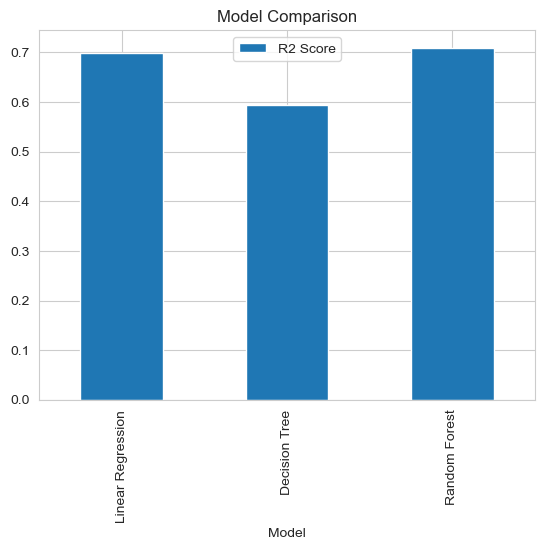

In [48]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest'],
    'RMSE': [rmse_lr, rmse_dt, rmse_rf],
    'MAE': [mae_lr, mae_dt, mae_rf],
    'R2 Score': [r2_lr, r2_dt, r2_rf]
})

results

results.plot(x='Model', y='R2 Score', kind='bar')
plt.title("Model Comparison")
plt.show()

# Top 5 Features Impacting House Price

In [49]:
feature_importance = pd.Series(rf.feature_importances_, index=X.columns)
top5 = feature_importance.sort_values(ascending=False).head(5)

top5

total_sqft        0.701545
bath              0.036368
balcony           0.029826
bhk               0.026605
location_Other    0.014438
dtype: float64

# Cross-Validation Performance
We evaluate model stability using 5-fold cross-validation.

In [50]:
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(
    rf,
    X,
    y,
    cv=3,    
    scoring='r2',
    n_jobs=1
)
cv_scores.mean()

np.float64(0.6786154266916693)

# Real Price Prediction (Original Scale)
We convert log predictions back to actual price values.

In [51]:
y_pred_real = np.exp(y_pred_rf)
y_test_real = np.exp(y_test)
rmse_real = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
mae_real = mean_absolute_error(y_test_real, y_pred_real)
rmse_real, mae_real

(np.float64(31.790130658387458), 17.401398498009318)

# Residual Analysis
We analyze the distribution of prediction errors.

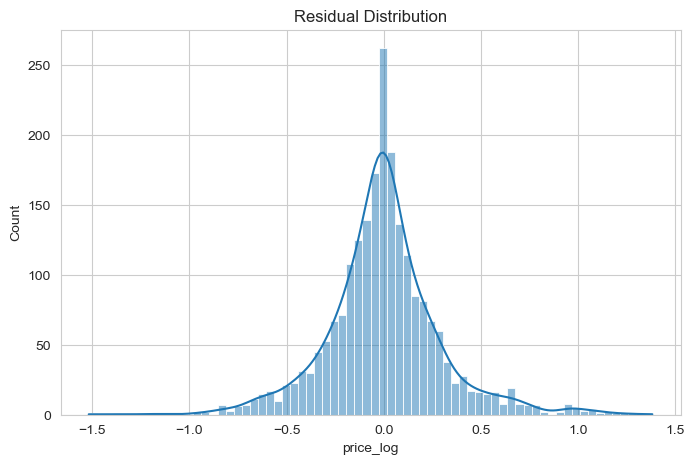

In [52]:
residuals = y_test - y_pred_rf
plt.figure(figsize=(8,5))
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

## Regularized Linear Model

In [53]:
from sklearn.linear_model import Ridge
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
r2_score(y_test, ridge.predict(X_test))

0.6984462969809511

# Limitations
- Model trained only on Bangalore housing data
- Does not include macroeconomic factors
- No time-based pricing trends
- Amenities and infrastructure factors excluded
# Future Improvements
- Add distance to metro, schools, IT hubs
- Include time-series trends
- Deploy model using Streamlit
- Add SHAP explainability

# Final Model Evaluation

The Random Forest model achieved:

- R² ≈ 0.71 (Test Set)
- Cross-validation R² ≈ 0.68
- RMSE ≈ ₹31.8 Lakhs
- MAE ≈ ₹17.4 Lakhs

The model demonstrates strong predictive capability
for estimating house prices in Bangalore.

Key insights:

1. Property size (total_sqft) is the dominant price driver.
2. Bathrooms and bedrooms positively influence valuation.
3. Location contributes significantly to price variation.
4. Ensemble models outperform linear models due to non-linear relationships.

The model can be used as a decision-support tool
for pricing and investment analysis.